In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('50_placement .csv')
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Placement')

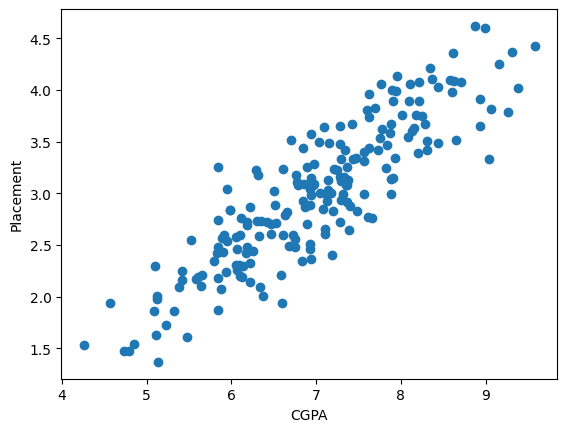

In [3]:
plt.scatter(df['cgpa'],df['package'])
plt.xlabel("CGPA")
plt.ylabel("Placement")

In [4]:
x=df.iloc[:,0:1]
y=df.iloc[:,-1]

In [5]:
x

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94
...,...
195,6.93
196,5.89
197,7.21
198,7.63


In [6]:
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [8]:
lr=LinearRegression()

In [9]:
lr.fit(x_train,y_train)

LinearRegression()

In [10]:
x_test.head()

,cgpa
112,8.58
29,7.15
182,5.88
199,6.22
193,4.57


In [11]:
y_test.head()

112    4.10
29     3.49
182    2.08
199    2.33
193    1.94
Name: package, dtype: float64

In [12]:
lr.predict(x_test.iloc[0].values.reshape(1,1))

c:\Users\niraj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.89111601])

In [13]:
lr.predict(x_test.iloc[1].values.reshape(1,1))

c:\Users\niraj\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.09324469])

Text(0, 0.5, 'Placement')

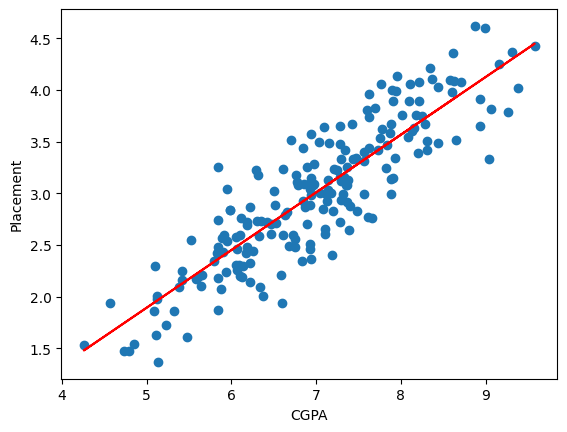

In [14]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(x_train,lr.predict(x_train),color='red')
plt.xlabel("CGPA")
plt.ylabel("Placement")

In [15]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [16]:
y_pred=lr.predict(x_test)

In [17]:
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [18]:
print("MAE",mean_absolute_error(y_test,y_pred))

MAE 0.2884710931878175


In [19]:
print("MSE",mean_squared_error(y_test,y_pred))

MSE 0.12129235313495527


In [20]:
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))

RMSE 0.34827051717731616


In [21]:
print("R2 score",r2_score(y_test,y_pred))
r2=r2_score(y_test,y_pred)

R2 score 0.780730147510384


In [22]:
#adjusted r2 score
x_test.shape

(40, 1)

Adjacented R2 score

In [23]:
1-((1-r2)*(40-1)/(40-1-1))

0.7749598882343415

In [24]:
new_df1=df.copy()
new_df1['rand']=np.random.random(200)
new_df1=new_df1[['cgpa','rand','package']]
new_df1.head()

,cgpa,rand,package
0,6.89,0.892395,3.26
1,5.12,0.128834,1.98
2,7.82,0.352936,3.25
3,7.42,0.618930,3.67
4,6.94,0.102188,3.57


Text(0, 0.5, 'package in lpa')

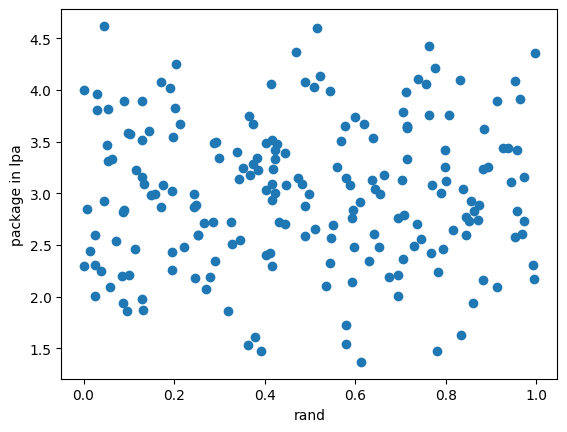

In [25]:
plt.scatter(new_df1['rand'],new_df1['package'])
plt.xlabel("rand")
plt.ylabel("package in lpa")

In [26]:
x=new_df1.iloc[:,0:2]
y=new_df1.iloc[:,-1]

In [27]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [28]:
lr=LinearRegression()

In [29]:
lr.fit(x_train,y_train)

LinearRegression()

In [30]:
y_pred1=lr.predict(x_test)

In [31]:
r2_score(y_test,y_pred1)


0.7818375582705639

In [32]:
r2=r2_score(y_test,y_pred1)

In [33]:
1-((1-r2)*(40-1)/(40-1-2))

0.7700449938527565